# Task 1

In [105]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([
    [1., 0.],
    [0., 1.],
    [1., 1.],
])
y = np.array([[1.], [2.], [1.]])

W1 = np.array([[1., -1.],
               [-1., 1.]])
b1 = np.array([0.5, 0.5])

W2 = np.array([[1.],
               [2.]])
b2 = np.array([0.])

n_params = W1.size + b1.size + W2.size + b2.size
print("architecture: 2 inputs -> hidden layer (2 ReLU units) -> 1 linear output")
print("1 hidden layer, 2 hidden units")
print("trainable params (incl. zeros): W1", W1.size, "+ b1", b1.size,
      "+ W2", W2.size, "+ b2", b2.size, "=", n_params)


architecture: 2 inputs -> hidden layer (2 ReLU units) -> 1 linear output
1 hidden layer, 2 hidden units
trainable params (incl. zeros): W1 4 + b1 2 + W2 2 + b2 1 = 9


architecture: 
2 inputs -> hidden layer (2 ReLU units) -> 1 linear output
1 hidden layer, 2 hidden units
trainable params: W1 4 + b1 2 + W2 2 + b2 1 = 9

In [106]:
def forward(X, W1, b1, W2, b2, use_relu=True):
    z1 = X @ W1 + b1
    h = np.maximum(0.0, z1) if use_relu else z1
    yhat = h @ W2 + b2
    return z1, h, yhat


print("  X", X.shape, "\n", " y", y.shape, "\n", " W1", W1.shape, "\n",
      " b1", b1.shape, "\n",
      " W2", W2.shape, "\n", " b2", b2.shape)
z1, h, yhat = forward(X, W1, b1, W2, b2)
print("  Z1", z1.shape,  "\n", " H", h.shape,  "\n", " Yhat", yhat.shape)


  X (3, 2) 
  y (3, 1) 
  W1 (2, 2) 
  b1 (2,) 
  W2 (2, 1) 
  b2 (1,)
  Z1 (3, 2) 
  H (3, 2) 
  Yhat (3, 1)


In [107]:
se = (yhat - y) ** 2

print(f"{'row':>3} {'z1':>16} {'h':>16} {'yhat':>7} {'y':>5} {'sq.err':>8}")
for i in range(len(X)):
    print(f"{i:3d} {str(np.round(z1[i], 2)):>16} {str(np.round(h[i], 2)):>16} "
          f"{yhat[i, 0]:7.2f} {y[i, 0]:5.2f} {se[i, 0]:8.4f}")

print()
print("mean loss (MSE, no 1/2 factor) =", se.mean())

print("\nsanity check row 0 z1 =", z1[0], "-> matches [1.5, -0.5]")
assert np.allclose(z1[0], [1.5, -0.5])


row               z1                h    yhat     y   sq.err
  0      [ 1.5 -0.5]        [1.5 0. ]    1.50  1.00   0.2500
  1      [-0.5  1.5]        [0.  1.5]    3.00  2.00   1.0000
  2        [0.5 0.5]        [0.5 0.5]    1.50  1.00   0.2500

mean loss (MSE, no 1/2 factor) = 0.5

sanity check row 0 z1 = [ 1.5 -0.5] -> matches [1.5, -0.5]


In [108]:
assert yhat.shape == y.shape
print("Yhat.shape == y.shape:", yhat.shape == y.shape)
print("Yhat (numpy) =", yhat.ravel())
print("residuals    =", (yhat - y).ravel())


Yhat.shape == y.shape: True
Yhat (numpy) = [1.5 3.  1.5]
residuals    = [0.5 1.  0.5]


In [109]:
z1n, hn, yhat_n = forward(X, W1, b1, W2, b2, use_relu=False)

print("without ReLU (H = Z1 directly):")
for i in range(len(X)):
    print(f"row {i}: z1 = {z1n[i]}  yhat = {yhat_n[i, 0]:.2f}  (with ReLU was {yhat[i, 0]:.2f})")


without ReLU (H = Z1 directly):
row 0: z1 = [ 1.5 -0.5]  yhat = 0.50  (with ReLU was 1.50)
row 1: z1 = [-0.5  1.5]  yhat = 2.50  (with ReLU was 3.00)
row 2: z1 = [0.5 0.5]  yhat = 1.50  (with ReLU was 1.50)


1. Why is the result affine once ReLU is removed?
2. Why do all rows share the same parameters, and why doesn't the parameter count depend on the number of examples?

1) Without ReLU, H is just Z1, and Z1 itself is X @ W1 + b1 - a linear map plus a constant. Then Yhat = H @ W2 + b2 is again a linear map of that plus another constant. Stacking linear-plus-constant on top of linear-plus-constant is still linear-plus-constant, that's the definition of affine. ReLU is the only thing that bends the line (it clips negative Z1 to 0), so once it's gone rows 0 and 1 change (they had a negative z1 entry) but row 2 doesn't (it was already non-negative).
2) W1, b1, W2, b2 are the same numbers for every row of X - the loop over rows doesn't change them, we just plug different X[i] in. That's the whole point of a "shared" weight matrix: the network doesn't get new weights per example, it applies the same function 3 times. So the number of parameters only depends on the shapes of W1, b1, W2, b2 (2x2 + 2 + 2x1 + 1 = 9), and adding a 4th or 100th row to X wouldn't change that count at all - it would just mean forward() runs on a bigger batch.

# Task 2

### Part A

In [110]:
y = np.array([1., 2., 4.])
yhat = np.array([0., 2., 7.])

res = yhat - y
mse_val = np.mean(res ** 2)
mae_val = np.mean(np.abs(res))
print("residuals =", res)
print("MSE =", mse_val, " MAE =", mae_val)

yhat2 = np.array([0., 2., 10.])
res2 = yhat2 - y
mse2 = np.mean(res2 ** 2)
mae2 = np.mean(np.abs(res2))
print()
print("last prediction changed to 10:")
print("residuals =", res2)
print("MSE =", mse2, " MAE =", mae2)


residuals = [-1.  0.  3.]
MSE = 3.3333333333333335  MAE = 1.3333333333333333

last prediction changed to 10:
residuals = [-1.  0.  6.]
MSE = 12.333333333333334  MAE = 2.3333333333333335


MSE jumped from 3.33 to 12.33 (roughly 3.7x) while MAE only went from 1.33 to 2.33 (about 1.75x). That's just because MSE squares the residual, so one big outlier (6 instead of 3) dominates the whole average, while MAE grows linearly with the error and treats it the same as a bunch of small errors would. So a smaller MSE doesn't automatically mean "better" than a smaller MAE -- they're on different scales and punish outliers differently, you have to pick the one that matches what you actually care about.

### Part B

In [111]:
y_bin = np.array([1., 0.])
pA = np.array([0.8, 0.2])
pB = np.array([0.6, 0.4])


def bce(y, p):
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))


for name, p in [("A", pA), ("B", pB)]:
    loss = bce(y_bin, p)
    pred = (p > 0.5).astype(int)
    acc = np.mean(pred == y_bin)
    print(f"model {name}: p = {p}  mean BCE = {loss:.4f}  pred@0.5 = {pred}  accuracy = {acc}")


model A: p = [0.8 0.2]  mean BCE = 0.2231  pred@0.5 = [1 0]  accuracy = 1.0
model B: p = [0.6 0.4]  mean BCE = 0.5108  pred@0.5 = [1 0]  accuracy = 1.0


Both models threshold to the same predicted classes ([1, 0]), so both get 100% accuracy -- accuracy only looks at which side of 0.5 you land on. BCE looks at how confident that prediction was: model A said 0.8/0.2 (confident and correct) while model B said 0.6/0.4 (barely on the right side), so A gets a much lower loss even though the hard classification is identical. This is also why you shouldn't threshold first and then compute BCE on the 0/1 predictions -- you'd throw away exactly the confidence information BCE is meant to measure.

### Part C

In [112]:
logits = np.array([0., np.log(3), 0.])
exp = np.exp(logits)
probs = exp / exp.sum()
correct_idx = 1
loss = -np.log(probs[correct_idx])

print("softmax probs =", probs, " sum =", probs.sum())
print("loss = -ln(p1) =", loss)
assert np.isclose(probs.sum(), 1.0)


softmax probs = [0.2 0.6 0.2]  sum = 1.0
loss = -ln(p1) = 0.5108256237659905


- (a) an unrestricted real value: a single linear (no activation) output unit, trained with MSE.
- (b) a yes/no outcome: one sigmoid output unit (a probability in [0,1]), trained with binary cross-entropy.
- (c) exactly one of three categories: three logits passed through softmax, trained with (multiclass) cross-entropy on the correct class's probability.

# Task 3

### Part A

In [113]:
X = np.array([[-2.], [-1.], [-0.5], [0.5], [1.], [2.]])
y = np.abs(X)

initial = {
    "W1": np.array([[0.5, -0.5]]),
    "b1": np.array([0., 0.]),
    "W2": np.array([[0.5], [0.5]]),
    "b2": np.array([0.]),
}


def forward(params, X):
    W1, b1, W2, b2 = params["W1"], params["b1"], params["W2"], params["b2"]
    Z1 = X @ W1 + b1
    H = np.maximum(0.0, Z1)
    Yhat = H @ W2 + b2
    return Z1, H, Yhat


def mse(params, X, y):
    _, _, Yhat = forward(params, X)
    assert Yhat.shape == y.shape
    return np.mean((Yhat - y) ** 2)


Z1, H, Yhat = forward(initial, X)
print("Z1", Z1.shape, " H", H.shape, " Yhat", Yhat.shape)
print()
for i in range(len(X)):
    print(f"x = {X[i, 0]:5.2f}  h = {H[i]}  yhat = {Yhat[i, 0]:.3f}  y = {y[i, 0]:.3f}")
print()
print("initial mean loss =", mse(initial, X, y))


Z1 (6, 2)  H (6, 2)  Yhat (6, 1)

x = -2.00  h = [0. 1.]  yhat = 0.500  y = 2.000
x = -1.00  h = [0.  0.5]  yhat = 0.250  y = 1.000
x = -0.50  h = [0.   0.25]  yhat = 0.125  y = 0.500
x =  0.50  h = [0.25 0.  ]  yhat = 0.125  y = 0.500
x =  1.00  h = [0.5 0. ]  yhat = 0.250  y = 1.000
x =  2.00  h = [1. 0.]  yhat = 0.500  y = 2.000

initial mean loss = 0.984375


In [114]:
print("sanity check at x = -2: hidden =", H[0], " yhat =", Yhat[0, 0])
assert np.allclose(H[0], [0., 1.])
assert np.isclose(Yhat[0, 0], 0.5)
print("matches the expected [0, 1] and 0.5 -- forward pass looks right")


sanity check at x = -2: hidden = [0. 1.]  yhat = 0.5
matches the expected [0, 1] and 0.5 -- forward pass looks right


### Part B

$$G = \frac{2}{N}(\hat{Y} - y), \qquad dW_2 = H^T G, \qquad db_2 = \sum_i G_i$$

$$D = (G W_2^T) \odot \mathbf{1}[Z_1 > 0], \qquad dW_1 = X^T D, \qquad db_1 = \sum_i D_i$$

(these are given, not derived -- the 1/N is already folded into G, so it isn't applied a second time anywhere downstream)

In [115]:
def gradients(params, X, y):
    W1, b1, W2, b2 = params["W1"], params["b1"], params["W2"], params["b2"]
    Z1, H, Yhat = forward(params, X)
    N = X.shape[0]

    G = (2.0 / N) * (Yhat - y)      
    dW2 = H.T @ G    
    db2 = G.sum(axis=0)    

    D = (G @ W2.T) * (Z1 > 0)   
    dW1 = X.T @ D         
    db1 = D.sum(axis=0)     

    return {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2}


grads0 = gradients(initial, X, y)
for name in ["W1", "b1", "W2", "b2"]:
    ok = grads0[name].shape == initial[name].shape
    print(f"{name}: grad shape {grads0[name].shape}  param shape {initial[name].shape}  {'OK' if ok else 'MISMATCH'}")
    print("   value:", grads0[name])


W1: grad shape (1, 2)  param shape (1, 2)  OK
   value: [[-0.65625  0.65625]]
b1: grad shape (2,)  param shape (2,)  OK
   value: [-0.4375 -0.4375]
W2: grad shape (2, 1)  param shape (2, 1)  OK
   value: [[-0.65625]
 [-0.65625]]
b2: grad shape (1,)  param shape (1,)  OK
   value: [-1.75]


### Run the experiment

In [116]:
params = {k: v.copy() for k, v in initial.items()}
old_loss = mse(params, X, y)
grads = gradients(params, X, y)

lr = 0.05
params = {name: params[name] - lr * grads[name] for name in params}
new_loss = mse(params, X, y)

print("one update, lr = 0.05")
print("old loss =", old_loss)
print("new loss =", new_loss)


one update, lr = 0.05
old loss = 0.984375
new loss = 0.7415765000805258


In [117]:
params = {name: value.copy() for name, value in initial.items()}
history = [mse(params, X, y)]

for step in range(300):
    grads = gradients(params, X, y)
    params = {name: params[name] - 0.05 * grads[name] for name in params}
    history.append(mse(params, X, y))

print("stored loss values:", len(history))
print("initial loss =", history[0])
print("final loss   =", history[-1])
assert len(history) == 301
assert history[-1] < history[0]


stored loss values: 301
initial loss = 0.984375
final loss   = 2.274200788567709e-06


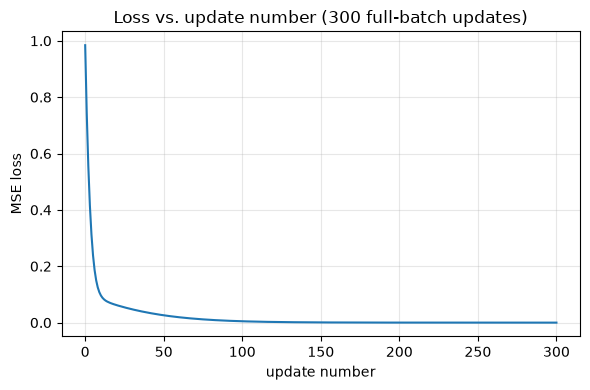

final predictions vs targets:
x = -2.00  yhat = 1.998  y = 2.000
x = -1.00  yhat = 1.001  y = 1.000
x = -0.50  yhat = 0.502  y = 0.500
x =  0.50  yhat = 0.502  y = 0.500
x =  1.00  yhat = 1.001  y = 1.000
x =  2.00  yhat = 1.998  y = 2.000
final MSE = 2.274200788567709e-06  (initial was 0.984375 )


In [118]:
plt.figure(figsize=(6, 4))
plt.plot(range(len(history)), history)
plt.xlabel("update number")
plt.ylabel("MSE loss")
plt.title("Loss vs. update number (300 full-batch updates)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

_, _, Yhat_final = forward(params, X)
print("final predictions vs targets:")
for i in range(len(X)):
    print(f"x = {X[i, 0]:5.2f}  yhat = {Yhat_final[i, 0]:.3f}  y = {y[i, 0]:.3f}")
print("final MSE =", mse(params, X, y), " (initial was", history[0], ")")


In [119]:
X_check = np.array([[-1.5], [-0.75], [0.75], [1.5]])
y_check = np.abs(X_check)
_, _, Yhat_check = forward(params, X_check)
check_mse = np.mean((Yhat_check - y_check) ** 2)

print("evaluation on X_check (no parameter update):")
for i in range(len(X_check)):
    print(f"x = {X_check[i, 0]:5.2f}  yhat = {Yhat_check[i, 0]:.3f}  y = {y_check[i, 0]:.3f}")
print("check MSE =", check_mse)


evaluation on X_check (no parameter update):
x = -1.50  yhat = 1.500  y = 1.500
x = -0.75  yhat = 0.751  y = 0.750
x =  0.75  yhat = 0.751  y = 0.750
x =  1.50  yhat = 1.500  y = 1.500
check MSE = 1.0093159510004993e-06


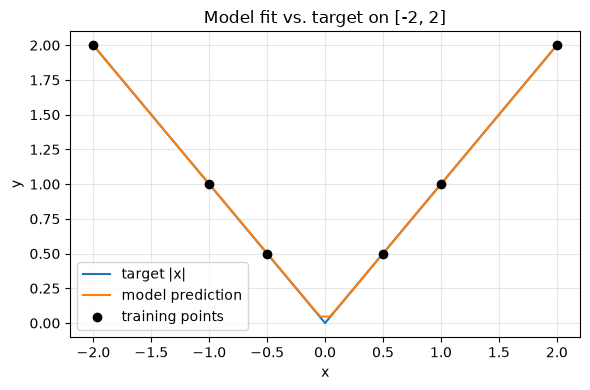

In [120]:
xs = np.linspace(-2, 2, 101).reshape(-1, 1)
_, _, ys_pred = forward(params, xs)

plt.figure(figsize=(6, 4))
plt.plot(xs, np.abs(xs), label="target |x|")
plt.plot(xs, ys_pred, label="model prediction")
plt.scatter(X, y, color="black", zorder=5, label="training points")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Model fit vs. target on [-2, 2]")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


1. Does the low loss on X_check mean the model generalizes well?
2. Why compute all four gradients before touching any parameter?

1) Not really - X_check is just more points sandwiched between the training points, on the same interval and the same |x| shape. Interpolating between points you've already seen is a much easier job than extrapolating outside [-2, 2] or handling a genuinely different function. So low MSE here just confirms the piecewise-linear fit is smooth between training points, it's not proof the model "understands" |x| in general.
2) Because every gradient in gradients() is computed using the same Z1, H, Yhat, which come from one single forward pass with the current params. If you updated W2 first and then computed dW1 using the already-updated W2, you'd be mixing two different points in parameter space into one gradient step, and the math (and the given formulas) assume everything is evaluated at the same fixed point.

### Optional gradient check

In [121]:
eps = 1e-5
idx = (0, 0)

p_plus = {k: v.copy() for k, v in initial.items()}
p_plus["W1"][idx] += eps
p_minus = {k: v.copy() for k, v in initial.items()}
p_minus["W1"][idx] -= eps

num_grad = (mse(p_plus, X, y) - mse(p_minus, X, y)) / (2 * eps)
an_grad = gradients(initial, X, y)["W1"][idx]

print("numerical grad W1[0,0] =", num_grad)
print("analytic  grad W1[0,0] =", an_grad)
print("abs diff =", abs(num_grad - an_grad))


numerical grad W1[0,0] = -0.6562499999973603
analytic  grad W1[0,0] = -0.65625
abs diff = 2.639666263348772e-12


Matches to about 1e-12, so the analytic gradient formula for W1 checks out at this point. This is one element at initialization, away from any ReLU corner, so it's evidence the formulas are implemented correctly -- not a full proof for every input.